In [117]:
%cd /Users/arikreuter/Documents/PhD/CausalPriorFitting/src

/Users/arikreuter/Documents/PhD/CausalPriorFitting/src


In [118]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [119]:
from priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from priors.causal_prior.noise_distributions.MixedDist import MixedDist
from priors.causal_prior.scm.SCM import SCM
from priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from priors.causal_prior.mechanisms.BaseMechanism import BaseMechanism
from priors.causal_prior.mechanisms.IgnoreParentsMechanism import IgnoreParentsMechanism
from priors.causal_prior.noise_distributions.DistributionInterface import Distribution
from priors.causal_prior.noise_distributions.ResamplingDist import ResamplingDist
import torch

In [120]:
NUM_NODES = 50
p = 0.5 
SEED = 43
NOISE_STD = 0.1
BATCH_SIZE = 1000

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
   num_nodes=NUM_NODES,
    p=p,
)

#new_edges = [(1, 2), 
#             #(1, 0), 
#             (0, 2)]
#graph.clear_edges()
#graph.add_edges_from(new_edges)



causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

# mechanisms 
mechanisms = {}
for node in causal_dag.nodes():
    # assign mechanisms
    mechanisms[node] = SampleMLPMechanism(
        input_dim=len(causal_dag.parents(node)),
        node_shape=(1,),  # scalar output

    )

# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = MixedDist(
        std = NOISE_STD
    )

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var] = MixedDist(
        std = NOISE_STD
    )



In [121]:
scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
    use_exogenous_mechanisms = True
)



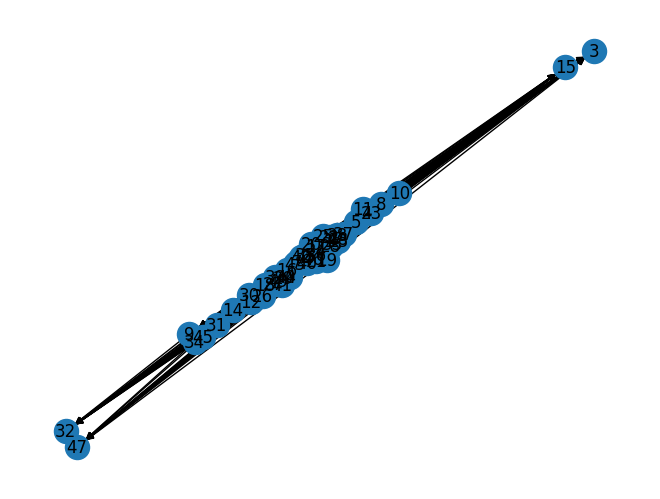

In [122]:
scm.dag.draw()

In [123]:
intervention_node = 0

In [124]:
#observational_sampling

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

obs0 = scm.propagate(num_samples=BATCH_SIZE)

In [125]:
obs0[intervention_node]

tensor([[-3.7047e-02],
        [-1.8017e-03],
        [ 1.0830e-01],
        [ 7.6821e-02],
        [-1.5467e-01],
        [-1.9098e-01],
        [-6.2984e-01],
        [-5.8184e-02],
        [-8.6366e-02],
        [ 4.6512e-02],
        [ 1.9609e-01],
        [ 7.0934e-02],
        [ 8.4970e-02],
        [ 1.3739e-01],
        [-2.7709e-02],
        [-9.9388e-02],
        [-6.1972e-02],
        [ 3.4711e-02],
        [ 6.9927e-03],
        [ 1.1344e-01],
        [ 1.6853e-02],
        [ 1.2548e-01],
        [-1.5509e-02],
        [-5.1548e-02],
        [-2.9380e-02],
        [-7.3568e-02],
        [ 1.2267e-01],
        [ 4.1369e-02],
        [ 2.2381e-01],
        [-2.3808e-01],
        [ 1.6082e-02],
        [ 6.9704e-02],
        [-7.5056e-03],
        [ 4.6661e-02],
        [-1.0081e-01],
        [ 6.6523e-02],
        [-5.3117e-02],
        [ 1.3151e-01],
        [ 1.8667e-02],
        [-1.5604e-02],
        [ 1.0825e-01],
        [-6.1125e-02],
        [ 9.9370e-02],
        [ 1

In [126]:
intervention_samples

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
      

In [127]:
# for interventional sampling, first determine intervention node

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

obs1 = scm.propagate(num_samples=BATCH_SIZE) #sample observational data again. 

intervention_samples = obs1[intervention_node] # collect set of observational samples for the intervention node

interventional_dist = ResamplingDist(intervention_samples) # create resampling distribution based on observational samples for the intervention node


scm.intervene(intervention_node)

if intervention_node in scm.dag.endogenous_variables():
    scm.endogenous_noise[intervention_node] = interventional_dist

if intervention_node in scm.dag.exogenous_variables():
    scm.exogenous_noise[intervention_node] = interventional_dist


scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

interv1 = scm.propagate(num_samples=BATCH_SIZE)


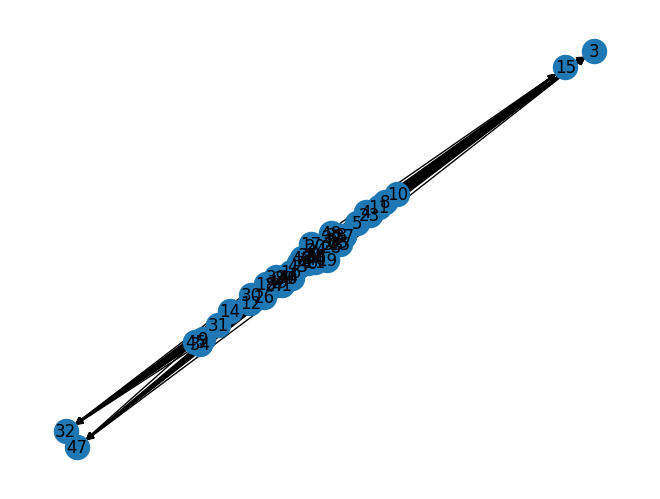

In [128]:
scm.dag.draw()

In [129]:
intervention_samples

tensor([[-9.1675e-02],
        [-1.0825e-01],
        [ 1.8622e-02],
        [-8.1497e-02],
        [ 5.9022e-03],
        [-4.3758e-02],
        [ 1.7607e-01],
        [ 3.3975e-01],
        [-6.4306e-02],
        [-8.4645e-02],
        [ 2.7605e-03],
        [ 6.2940e-02],
        [-1.6731e-01],
        [-1.1198e-01],
        [ 8.3383e-02],
        [-7.5155e-02],
        [ 4.7241e-02],
        [ 1.4285e-02],
        [ 6.2121e-02],
        [ 1.3412e-01],
        [ 5.8375e-02],
        [ 1.7696e-01],
        [ 9.0733e-02],
        [ 4.6203e-04],
        [-1.2283e-01],
        [-1.5373e-01],
        [ 1.0022e-01],
        [ 1.9912e-02],
        [ 6.8940e-02],
        [-1.7067e-01],
        [-1.6146e-01],
        [ 7.9947e-02],
        [-6.1813e-02],
        [-2.8611e-03],
        [ 3.4430e-02],
        [ 1.2239e-02],
        [-1.0260e-02],
        [ 1.0742e-02],
        [ 2.7038e-02],
        [-1.5216e-01],
        [-1.0263e-01],
        [-5.8308e-02],
        [-1.4256e-01],
        [-3

In [130]:
interventional_dist.sample_n(100)

tensor([-0.1175, -0.1698, -0.1552, -0.3410, -0.0049, -0.0084, -0.0030, -0.0173,
        -0.1615, -0.0945, -0.0926,  0.0156,  0.0125,  0.0908,  0.0950,  0.0169,
        -0.1240,  0.1826, -0.0356,  0.0143,  0.0532, -0.0140, -0.0472,  0.0530,
        -0.0159,  0.0151,  0.0059, -0.0241,  0.0334, -0.0623, -0.0164,  0.0197,
         0.1167,  0.0240,  0.1672, -0.0053, -0.0403, -0.0979, -0.1255, -0.0515,
         0.0799, -0.1082,  0.1049, -0.0755,  0.0187, -0.2250,  0.0363, -0.1122,
        -0.0438,  0.0228,  0.0927,  0.1836, -0.0241, -0.0025, -0.0794, -0.1640,
         0.0872, -0.0024, -0.0261,  0.1127, -0.0619, -0.1637, -0.0925, -0.0588,
        -0.0694, -0.0909, -0.0240,  0.0716, -0.0448, -0.0938, -0.1264, -0.0512,
        -0.1147,  0.1266, -0.0645,  0.0768, -0.0785,  0.2693, -0.1335,  0.0147,
         0.0604,  0.0576, -0.0419,  0.0073,  0.0369, -0.0392, -0.0717, -0.0337,
         0.0611, -0.1033,  0.0137,  0.0042, -0.0054, -0.0503, -0.0353,  0.0544,
        -0.0740, -0.2164, -0.0252,  0.19

In [132]:
interv1[intervention_node]

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
      